<a href="https://colab.research.google.com/github/rparson4/MarsTharsisGlaciers/blob/main/MarsMap_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Orthographic Projection Map of Mars

This notebook will generate an orthographic projection map of Mars, focusing on the western hemisphere, with latitude and longitude lines, and a specific transparent box highlighted.

In [ ]:
# Install cartopy for map projections
!pip install cartopy

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.image as mpimg
import numpy as np
import requests
import os

# Download a Mars global map image
image_url = 'https://upload.wikimedia.org/wikipedia/commons/e/ee/Mars_Viking_MDIM21_ClrShad_merge_global_232m.jpg'

* Create custom image by downloading the JPEG image above, and

* scaling down horiz and vert dimensions each by 33% (roughly 10x less pixels). This will avoid a memory crash error that even increasing Pillow's decompression bomb limit was unable to address.
Save this image as 'MarsMap.jpg'

Shape of mars_img: (3521, 7042, 3)


/tmp/ipykernel_8884/860967706.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((box_lon_min, box_lat_min), # (x, y) lower-left corner


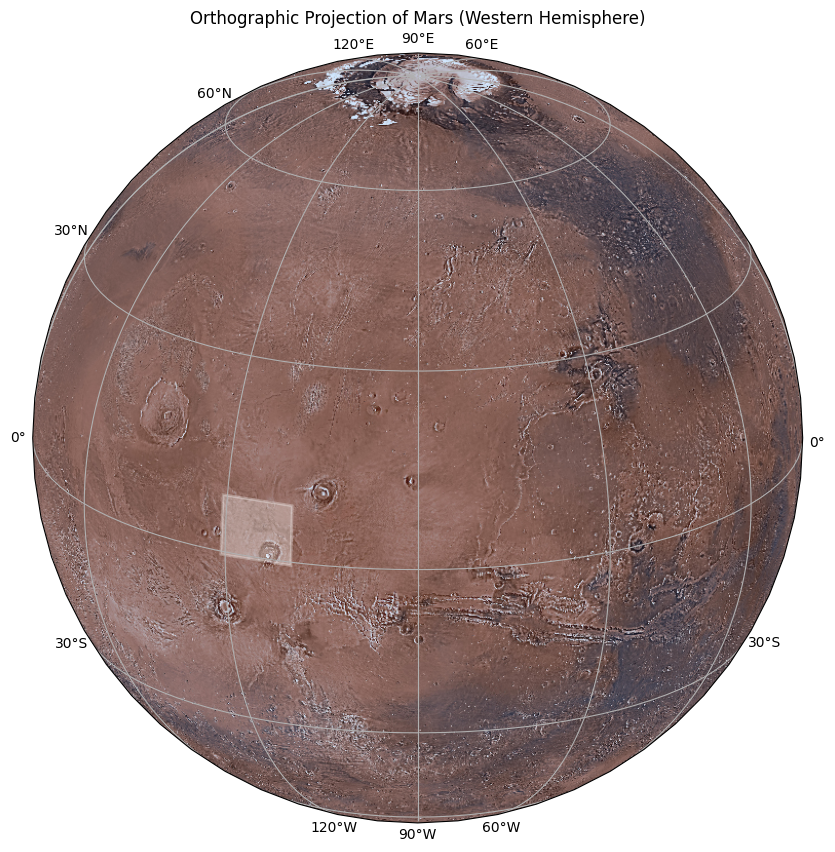

In [ ]:

image_path = 'MarsMap.jpeg'

# Increase Pillow's decompression bomb limit to handle large images (might not be strictly needed for this smaller image, but good practice)
from PIL import Image
Image.MAX_IMAGE_PIXELS = None # Disable the limit or set a higher value like 1_000_000_000

mars_img = mpimg.imread(image_path)
print(f"Shape of mars_img: {mars_img.shape}") # Debugging: check if image loaded correctly

# Create the figure and axes with an orthographic projection centered on the western hemisphere
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=-90, central_latitude=20))

# Add the Mars image to the map. The image is assumed to be a Plate Carree (rectangular) projection.
# Extent is -180 to 180 longitude and -90 to 90 latitude.
ax.imshow(mars_img, origin='upper', transform=ccrs.PlateCarree(),
          extent=[-180, 180, -90, 90])

# Add gridlines for latitude and longitude every 30 degrees
gridlines = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gridlines.xlines = True
gridlines.ylines = True
gridlines.xlocator = plt.FixedLocator(np.arange(-180, 181, 30))
gridlines.ylocator = plt.FixedLocator(np.arange(-90, 91, 30))

# Define the transparent box coordinates
# Latitude: 0 to 9N
# Longitude: 109W to 120W (which is -109 to -120 in standard longitude)
box_lon_min = -120.75
box_lon_max = -109.25
box_lat_min = -0.5
box_lat_max = 8.75

# Create and add the transparent box
# Use PlateCarree transform for coordinates
ax.add_patch(plt.Rectangle((box_lon_min, box_lat_min), # (x, y) lower-left corner
                           box_lon_max - box_lon_min,  # width
                           box_lat_max - box_lat_min,  # height
                           color='white', alpha=0.3,     # color and transparency
                           transform=ccrs.PlateCarree(),
                           fill=True, edgecolor='white', linewidth=2))

ax.set_title('Orthographic Projection of Mars (Western Hemisphere)')

plt.savefig('mars_map_output.png') # Save the figure as a file
plt.show()

In [ ]:
# This cell is no longer needed as its content has been merged with the previous cell.